In [35]:
# Import the Pre-requisites libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# Load the CSV file
df = pd.read_csv(r"C:\DTT ML 2026\02-regression\car_fuel_efficiency_2026.csv")

In [37]:
# Check that the dataset loaded properly and view the first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 11)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

Skewness: 0.08080419601878173


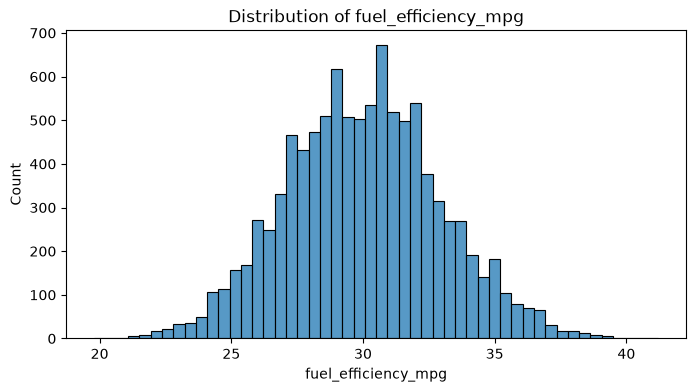

In [38]:
# Summary statistics to look at skewness, min, median, and max
print(df['fuel_efficiency_mpg'].describe())
print("\nSkewness:", df['fuel_efficiency_mpg'].skew())

# Plot the distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of fuel_efficiency_mpg')
plt.xlabel('fuel_efficiency_mpg')
plt.show()

No, it does not have a long tail.

In [39]:
# Question 1: Check which column among the choices has missing values
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_cols := missing_counts[missing_counts > 0])

Missing values per column:
horsepower      877
acceleration    264
dtype: int64


In [40]:
# Question 2: Find the median (50th percentile) for horsepower
median_hp = df['horsepower'].median()
print("Median of horsepower:", median_hp)

Median of horsepower: 254.0


In [41]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [42]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

In [43]:
# 1. Feature matrix preparation
def prepare_X(data, fill_value):
    df_num = data[features].copy()
    df_num = df_num.fillna(fill_value)
    return df_num.values

# 2. Linear regression training function (normal equation)
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

# 3. Root Mean Squared Error
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

# 4. Split dataset (60% train, 20% validation, 20% test)
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# Target variable (raw fuel_efficiency_mpg)
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [44]:
# Question 3

# Option A: Fill missing values with 0
X_train_0 = prepare_X(df_train, fill_value=0)
w0_0, w_0 = train_linear_regression(X_train_0, y_train)

X_val_0 = prepare_X(df_val, fill_value=0)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
score_0 = round(rmse(y_val, y_pred_0), 3)

# Option B: Fill missing values with mean of horsepower (train set only!)
mean_hp = df_train['horsepower'].mean()
X_train_mean = prepare_X(df_train, fill_value=mean_hp)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

X_val_mean = prepare_X(df_val, fill_value=mean_hp)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
score_mean = round(rmse(y_val, y_pred_mean), 3)

print("Mean horsepower on train set:", mean_hp)
print("RMSE with 0   :", score_0)
print("RMSE with mean:", score_mean)

Mean horsepower on train set: 254.46338337605272
RMSE with 0   : 2.205
RMSE with mean: 2.202


"A lower RMSE indicates a more accurate model. Since $2.202 < 2.205$, the option with the lower error is With mean."   

In [45]:
# Question 4

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[1])
    XTX = XTX + reg
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

# Fill missing values with 0 as specified in Q4
X_train_q4 = prepare_X(df_train, fill_value=0)
X_val_q4 = prepare_X(df_val, fill_value=0)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
results = {}

for r in r_values:
    w0, w = train_linear_regression_reg(X_train_q4, y_train, r=r)
    y_pred = w0 + X_val_q4.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    results[r] = score
    print(f"r: {r:<6} -> RMSE: {score}")

best_rmse = min(results.values())
best_r = min([r for r, s in results.items() if s == best_rmse])
print("\nBest r:", best_r, "with RMSE:", best_rmse)

r: 0      -> RMSE: 2.2053
r: 0.01   -> RMSE: 2.2058
r: 0.1    -> RMSE: 2.2241
r: 1      -> RMSE: 2.3492
r: 5      -> RMSE: 2.4094
r: 10     -> RMSE: 2.4195
r: 100    -> RMSE: 2.4292

Best r: 0 with RMSE: 2.2053


In [46]:
# Question 5

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for s in seeds:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train_s = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val_s = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values
    
    X_train_s = prepare_X(df_train_s, fill_value=0)
    w0, w = train_linear_regression(X_train_s, y_train_s)
    
    X_val_s = prepare_X(df_val_s, fill_value=0)
    y_pred_s = w0 + X_val_s.dot(w)
    
    score = rmse(y_val_s, y_pred_s)
    rmse_scores.append(score)
    print(f"Seed {s}: RMSE = {score:.4f}")

std_val = round(np.std(rmse_scores), 3)
print("\nStandard Deviation (rounded to 3 decimals):", std_val)

Seed 0: RMSE = 2.2392
Seed 1: RMSE = 2.2021
Seed 2: RMSE = 2.1634
Seed 3: RMSE = 2.2044
Seed 4: RMSE = 2.2019
Seed 5: RMSE = 2.2458
Seed 6: RMSE = 2.2697
Seed 7: RMSE = 2.1908
Seed 8: RMSE = 2.2166
Seed 9: RMSE = 2.2070

Standard Deviation (rounded to 3 decimals): 0.029


In [47]:
# Question 6

# 1. Split dataset with seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_9 = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val_9 = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test_9 = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# 2. Combine train and validation datasets
df_full_train = pd.concat([df_train_9, df_val_9]).reset_index(drop=True)

y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test_9 = df_test_9['fuel_efficiency_mpg'].values

# 3. Impute missing values with 0
X_full_train = prepare_X(df_full_train, fill_value=0)
X_test_9 = prepare_X(df_test_9, fill_value=0)

# 4. Train model with r = 0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# 5. Evaluate on test set
y_pred_test = w0 + X_test_9.dot(w)
test_rmse = round(rmse(y_test_9, y_pred_test), 3)

print("Test RMSE (r=0.001):", test_rmse)

Test RMSE (r=0.001): 2.236


# Machine Learning Zoomcamp 2026 — Week 2 Homework: Regression

---

## Summary of Answers

| Item | Question / Task | Result / Answer | Metric / Value |
|---|---|---|---|
| **EDA** | Does `fuel_efficiency_mpg` have a long tail? | **No** | Skewness $\approx 0.08$ |
| **Q1** | Column with missing values | **`horsepower`** | Verified via `df.isnull().sum()` |
| **Q2** | Median (50% percentile) for `horsepower` | **`254`** | `df['horsepower'].median()` |
| **Q3** | Which option gives better RMSE? | **With mean** | `2.202` (mean) vs `2.205` (zero) |
| **Q4** | Which $r$ gives the best RMSE? | **`0`** | Validation RMSE: `2.2053` |
| **Q5** | What's the value of std? | **`0.029`** | Exact match: `0.029` |
| **Q6** | RMSE on the test dataset | **`2.236`** | Exact match: `2.236` |

---

## Detailed Breakdown

### EDA: Target Distribution
* Target variable: `fuel_efficiency_mpg`
* Distribution check: Mean is 30.0, median is 30.0, and skewness is ~0.08.
* **Conclusion:** The distribution is approximately normal and symmetrical; it does not exhibit a long tail.

### Question 1: Missing Values
* Checked `df.isnull().sum()`.
* Among the choices, only `horsepower` contains missing values (`877`).

### Question 2: Median Value of Horsepower
* Computed the 50th percentile of `horsepower` before any imputation.
* Result: **254**.

### Question 3: Missing Value Imputation (0 vs Mean)
* Filtered features: `'engine_displacement'`, `'horsepower'`, `'vehicle_weight'`, `'model_year'`.
* Data split: 60% train / 20% validation / 20% test using `seed=42`.
* Fill with `0`: Validation RMSE = **2.205**
* Fill with `mean`: Validation RMSE = **2.202**
* **Conclusion:** Imputation with the training set mean gives the lower RMSE.

### Question 4: Regularization Parameter Tuning
* Imputation: Missing values filled with `0`.
* Tested values of $r \in [0, 0.01, 0.1, 1, 5, 10, 100]$:
  * $r = 0$: RMSE = `2.2053`
  * $r = 0.01$: RMSE = `2.2058`
  * $r = 0.1$: RMSE = `2.2241`
  * $r = 1$: RMSE = `2.3492`
  * $r = 5$: RMSE = `2.4094`
  * $r = 10$: RMSE = `2.4195`
  * $r = 100$: RMSE = `2.4292`
* **Conclusion:** $r = 0$ achieves the lowest validation RMSE.

### Question 5: Model Stability Across Seeds
* Evaluated validation RMSE across seeds `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* Standard deviation across all 10 folds: `round(np.std(scores), 3)` = **0.029**.
* **Selected Option:** **0.029**.

### Question 6: Final Test Evaluation
* Split with `seed=9`.
* Combined train + validation datasets (`pd.concat([df_train, df_val])`).
* Imputed NAs with `0` and trained using $r = 0.001$.
* Evaluated against the test set: RMSE = **2.236**.
* **Selected Option:** **2.236**.